# 04 — Validación

Se audita el modelo entrenado en la notebook 03:

1. **Qué aprendió** — los pesos por palabra de la Regresión Logística.
2. **Similitud coseno** — la métrica de clase que pide la consigna.
3. **Conclusiones finales.**

**Entrada:** los modelos y métricas de la notebook 03.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (9, 5)

PROCESSED = Path("..") / "data" / "processed"
MODELS = Path("..") / "models"

df = pd.read_parquet(PROCESSED / "train_clean.parquet")
vec_tfidf = joblib.load(MODELS / "vec_tfidf.joblib")
lr = joblib.load(MODELS / "lr.joblib")
metricas = joblib.load(MODELS / "metricas.joblib")

print("Modelos cargados (entrenados en la notebook 03, no se re-entrena nada acá)")
print(f"  vocabulario TF-IDF: {len(vec_tfidf.vocabulary_):,} palabras")
print(f"  F1 macro test (Reg. Logística): {metricas['reg_logistica']['f1_macro_test']:.4f}")

Modelos cargados (entrenados en la notebook 03, no se re-entrena nada acá)
  vocabulario TF-IDF: 50,000 palabras
  F1 macro test (Reg. Logística): 0.8242


## 1. ¿Qué aprendió el modelo?

### ¿Qué aprendió el modelo?

La Regresión Logística **se puede auditar**: aprende **un peso por palabra**.

Peso **positivo** → empuja a positivo. **Negativo** → empuja a negativo.

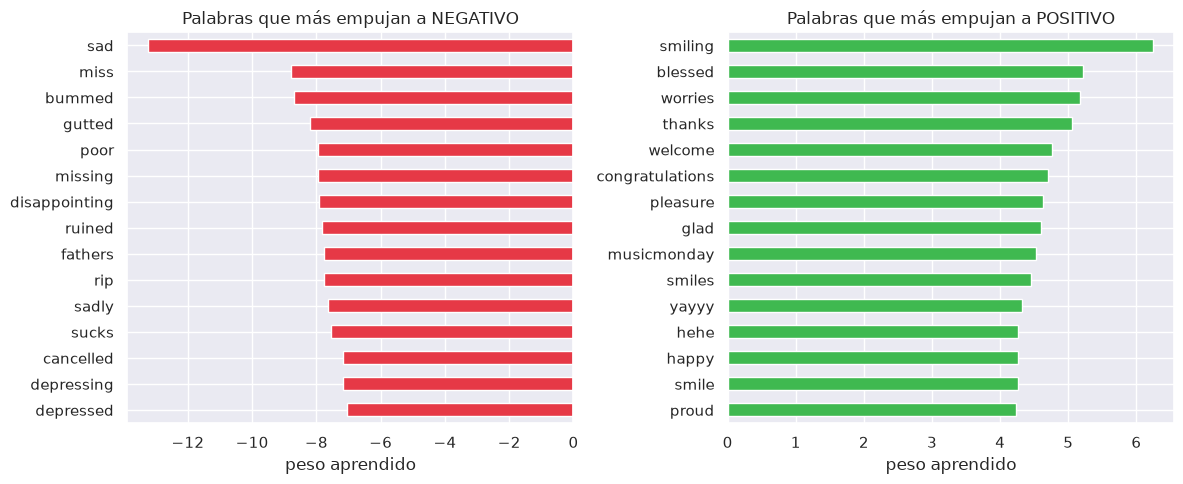

El modelo suma los pesos de cada palabra:
  'good'       = good(+3.69)                      = +3.69 -> POSITIVO
  'not good'   = not(-5.39) good(+3.69)           = -1.70 -> NEGATIVO
  'not bad'    = not(-5.39) bad(-3.99)            = -9.38 -> NEGATIVO


In [2]:
# Un peso por palabra: positivo empuja a la clase 1, negativo a la clase -1
pesos = pd.Series(lr.coef_[0], index=vec_tfidf.get_feature_names_out()).sort_values()
top_neg, top_pos = pesos.head(15), pesos.tail(15)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
top_neg.sort_values(ascending=False).plot(kind="barh", ax=ax[0], color="#E63946")
ax[0].set_title("Palabras que más empujan a NEGATIVO"); ax[0].set_xlabel("peso aprendido")
top_pos.plot(kind="barh", ax=ax[1], color="#3FB950")
ax[1].set_title("Palabras que más empujan a POSITIVO"); ax[1].set_xlabel("peso aprendido")
plt.tight_layout()
plt.show()

# El modelo puntua un tweet SUMANDO los pesos de sus palabras. ¿Que pasa con la negacion?
print("El modelo suma los pesos de cada palabra:")
for frase in ["good", "not good", "not bad"]:
    total = sum(pesos.get(p, 0) for p in frase.split())
    detalle = " ".join(f"{p}({pesos.get(p, 0):+.2f})" for p in frase.split())
    print(f"  {frase!r:12} = {detalle:32} = {total:+.2f} -> {'POSITIVO' if total > 0 else 'NEGATIVO'}")

**Conclusión — qué aprendió el modelo**

- Aprendió **solo**, de 1.6M de tweets. Nadie le dijo qué significa cada palabra.
- **Vocabulario que TextBlob jamás tendría:** `bummed`, `gutted`, `yayyy`, `hehe`, `sucks`, `rip` → **acá se ven los 23 puntos de ventaja**.
- **`musicmonday`** = un hashtag (448 tweets, 90% positivos) → **la decisión de conservar hashtags pagó**.

**🔍 `worries` figura como POSITIVA (+5.2) — ¿error?**
No: **el 88% de los `worries` son "no worries"** (= "de nada"), y el 86% son positivos. Bag-of-words separó el `no`, pero como la palabra casi siempre viene negada, **el modelo le pegó el significado de la frase entera a una sola palabra**. Acertó por fuerza bruta, no porque entienda.

**El límite, medido:**
```
'not good' = not(-5.39) + good(+3.69) = -1.70 -> NEGATIVO ✅ (zafa: 'not' pesa más)
'not bad'  = not(-5.39) + bad(-3.99)  = -9.38 -> NEGATIVO ❌ ('not bad' es elogio)
```
→ **Una suma no tiene orden.** Ese es el techo estructural.

## 2. Métrica de clase: similitud coseno

Se usa **similitud coseno** sobre TF-IDF para:
- **(a)** buscar los tweets más parecidos a uno de ejemplo
- **(b)** ver si los tweets del **mismo** sentimiento se parecen más entre sí que con los del **opuesto**

Se **reutiliza `vec_tfidf`** (ya entrenado con los 1.6M) — sólo `transform`.

*Muestra de 20.000: comparar de a pares crece al cuadrado; los 800.000 positivos entre sí serían 640.000 millones de pares.*

In [3]:
# Se reutiliza vec_tfidf, el vectorizador YA entrenado sobre los 1.6M tweets (notebook 03),
# en vez de entrenar uno nuevo: el vocabulario y los pesos IDF salen del corpus completo,
# como pide la consigna. Por eso .transform() y no .fit_transform().
#
# La muestra de 20.000 es para el analisis intra/inter de la celda siguiente, donde hay que
# comparar tweets de a pares: los 800.000 positivos entre si darian 640.000 millones de pares,
# inviable. Aca (1 tweet contra la muestra) el costo es bajo; se usa la misma muestra por
# consistencia entre las dos celdas.
sample_cos = df.sample(20000, random_state=42).reset_index(drop=True)
X_cos = vec_tfidf.transform(sample_cos["text_clean"])   # solo transform
print(f"Muestra: {X_cos.shape[0]} tweets | vocabulario (de los 1.6M): {X_cos.shape[1]} términos")

ejemplo_idx = sample_cos.index[sample_cos["text_clean"].str.split().str.len() > 4][0]
ejemplo_text = sample_cos["text_clean"].iloc[ejemplo_idx]
sims = cosine_similarity(X_cos[ejemplo_idx], X_cos).flatten()
top5 = sims.argsort()[::-1][1:6]   # [1:6] y no [0:5]: la posicion 0 es el tweet consigo mismo (1.0)

print(f"\nTweet de ejemplo: {ejemplo_text!r}\n")
print("Los 5 tweets más similares (similitud coseno sobre TF-IDF):")
for i in top5:
    print(f"  {sims[i]:.3f}  {sample_cos['text_clean'].iloc[i]!r}")

Muestra: 20000 tweets | vocabulario (de los 1.6M): 50000 términos



Tweet de ejemplo: 'i dont feel too good'

Los 5 tweets más similares (similitud coseno sobre TF-IDF):
  0.716  'i have go flu dont feel too good'
  0.698  "i don't feel too good"
  0.674  'i feel good'
  0.564  'good morning today i dont feel anything right'
  0.550  "don't feel good"


,Comparación,Similitud coseno promedio
0,Positivo vs Positivo (intra),0.017124
1,Negativo vs Negativo (intra),0.018410
2,Positivo vs Negativo (inter),0.014633


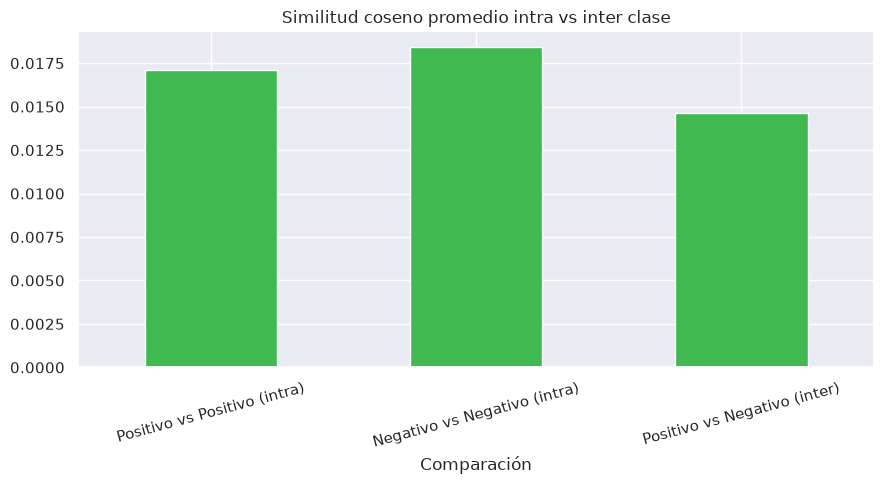

In [4]:
pos_idx = np.where(sample_cos["polarity"].values == 4)[0]
neg_idx = np.where(sample_cos["polarity"].values == 0)[0]
rng = np.random.default_rng(42)
pos_sub = rng.choice(pos_idx, size=min(600, len(pos_idx)), replace=False)
neg_sub = rng.choice(neg_idx, size=min(600, len(neg_idx)), replace=False)

sim_pos_pos = cosine_similarity(X_cos[pos_sub]).mean()
sim_neg_neg = cosine_similarity(X_cos[neg_sub]).mean()
sim_pos_neg = cosine_similarity(X_cos[pos_sub], X_cos[neg_sub]).mean()

resumen_sim = pd.DataFrame({
    "Comparación": ["Positivo vs Positivo (intra)", "Negativo vs Negativo (intra)", "Positivo vs Negativo (inter)"],
    "Similitud coseno promedio": [sim_pos_pos, sim_neg_neg, sim_pos_neg],
})
display(resumen_sim)

resumen_sim.set_index("Comparación").plot(kind="bar", legend=False, color=["#3FB950", "#E63946", "#8B949E"])
plt.title("Similitud coseno promedio intra vs inter clase")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Conclusión**

| comparación | similitud |
|---|---|
| Negativo vs Negativo (intra) | 0.0184 |
| Positivo vs Positivo (intra) | 0.0171 |
| Positivo vs Negativo (inter) | **0.0146** |

- Los valores son bajísimos (tweets de ~12 palabras sobre 50.000 columnas) → **lo que importa es la comparación relativa**.
- **Intra > inter**: el espacio TF-IDF **sí capta sentimiento**... pero apenas un **20% más**.
- → Señal **débil** = coherente con un techo en 82% y no en 95%. **Explica por qué el techo está donde está.**

**🔍 El límite se ve solo:** para `'i dont feel too good'`, el 3er tweet más parecido es `'i feel good'` (0.674) — **sentimiento opuesto**. Difieren solo en `dont`, la palabra que invierte todo.
→ **TF-IDF mide solapamiento de palabras, no significado.**

## Conclusiones

### Resultados

| Modelo | F1 train | F1 test | Gap |
|---|---|---|---|
| TextBlob (pre-entrenado) | — | 0.43 | — |
| BoW + Naive Bayes | 0.7907 | 0.8189 | −0.028 |
| TF-IDF + Reg. Logística | 0.8060 | **0.8245** | −0.018 |

*Azar = 0.50 (train balanceado 50/50)*

### Hallazgos

**1. Entrenar sobre el dominio gana por lejos: 0.82 vs 0.59.**
TextBlob no puntúa mal lo negativo — **no lo ve**. Su léxico es simétrico (`good`=+0.70, `bad`=−0.70), pero **nadie tuitea "bad"**: se queja con `aching`, `ponzi`, que valen 0.00.

**2. Ningún modelo sobreajusta: los gaps son negativos.**
El test rinde mejor que el train porque el train está etiquetado por emoticón (ruidoso) y el test a mano (limpio). **El 79-81% de train es el techo del ruido, no del modelo.**

**3. Los dos modelos empatan (~0.82).**
El cuello de botella es **la representación, no el algoritmo**: `'not bad'` = `not`(−5.39) + `bad`(−3.99) = **negativo**, cuando es un elogio. Una suma no tiene orden. Se rompe con **n-gramas o BERT**, no con otro clasificador.

**4. El EDA anticipó el techo y encontró señal descartada.**
El largo no discrimina; el vocabulario se comparte entre clases; el coseno lo confirma (intra 0.018 vs inter 0.015, apenas 20% más). Y las marcas de Twitter (URL +17.6 pts, @mención +17.2) **sí tienen señal, pero la limpieza las borra**.

**5. La clase neutral es una limitación estructural.**
No existe en el train. Contra el test completo la accuracy cae de 0.82 a 0.59.

### Decisión final

**Elegiría TF-IDF + Regresión Logística.** No por el F1 (empata dentro del margen de error) sino porque:
- da **probabilidades calibrables** → se puede mover el umbral según el negocio
- sus **coeficientes son auditables** palabra por palabra

**Pero la mejora real no viene de cambiar el modelo:** viene de **etiquetar datos a mano** con las tres clases. Los gaps negativos lo prueban — el modelo ya rinde por encima de la calidad de sus propias etiquetas.